In [1]:
import scanpy as sc
import infercnvpy as cnv
import pandas as pd
from scipy import sparse as sp

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import numpy as np

In [5]:
adata = sc.read_h5ad('../../3_figure_FFPE/output/GBM_BC002_infercnv.h5ad')

adata.obs['cell_type'] = pd.read_csv('../../3_figure_FFPE/output/GBM_cell_type_labels.txt', sep='\t', index_col=0)['cell_type']



In [6]:
palette = {
    # Malignant GBM subtypes (single bold cool scheme)
    'OPC': "#D7ECF3",  # very light icy blue
    'NPC': "#4EA8DE",  # vivid blue
    'MES': "#2A9D8F",  # saturated teal-green
    'AC':  "#1B4332",  # deep forest green

    # Non-malignant (independent categorical)
    'Macrophage':      "#C44536",  # brick red
    'T cell':          "#6A4C93",  # purple
    'Endothelial':     "#F4A261",  # orange
    'Oligodendrocyte': "#B08968",  # tan
    'Neuronal':       "#5F6C7B",  # neutral grey
}

adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
order = ["OPC","NPC","MES","AC","Macrophage","T cell","Endothelial","Oligodendrocyte","Neuronal"]
adata.obs["cell_type"] = adata.obs["cell_type"].cat.reorder_categories(order, ordered=True)
adata.uns["cell_type_colors"] = np.array([palette[c] for c in order], dtype=object)



In [7]:
n_sample = 1000
sample = []
for cell_type in adata.obs['cell_type'].unique():
    cell_df = adata.obs.loc[adata.obs['cell_type'] == cell_type]
    if n_sample < len(cell_df):
        sample.extend(cell_df.sample(n_sample).index)
    else:
        sample.extend(cell_df.index)


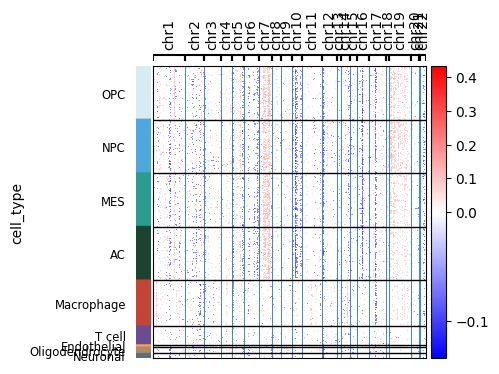

In [8]:
cnv.pl.chromosome_heatmap(
    adata[sample],
    groupby="cell_type",
    dendrogram=False,
    show=False,figsize=(4,4) 
)

plt.savefig('../plots/cnv_heatmap.pdf')

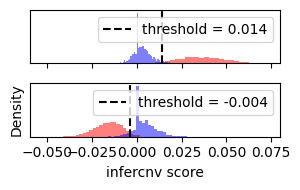

In [9]:
### determine thresholds for chr7 and chr10

fig,(ax, ax2) = plt.subplots(2,1, figsize=(3,2), sharex=True)
ax.hist(adata[adata.obs['infercnv']=='tumor'].obs['chr7_copy_number'], bins=50, alpha=0.5, color='red',density=True)
ax.hist(adata[adata.obs['infercnv']=='normal'].obs['chr7_copy_number'], bins=50, alpha=0.5, color='blue',density=True)
threshold = (0.014)
ax.axvline(threshold, color = 'k', linestyle = '--', label='threshold = ' + str(threshold))
ax.legend()
ax.set_yticks([])

ax2.hist(adata[adata.obs['infercnv']=='tumor'].obs['chr10_copy_number'], bins=50, alpha=0.5, color='red',density=True)
ax2.hist(adata[adata.obs['infercnv']=='normal'].obs['chr10_copy_number'], bins=50, alpha=0.5, color='blue',density=True)
threshold = (-0.004)
ax2.axvline(threshold, color = 'k', linestyle = '--', label='threshold = ' + str(threshold))
ax2.legend()
ax2.set_xlim(-0.06, 0.08)
ax2.set_yticks([])
ax2.set_xlabel('infercnv score')

ax2.set_ylabel('Density')
plt.tight_layout()

plt.savefig('../plots/infercnv_chr7_chr10_thresholds.pdf')